In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

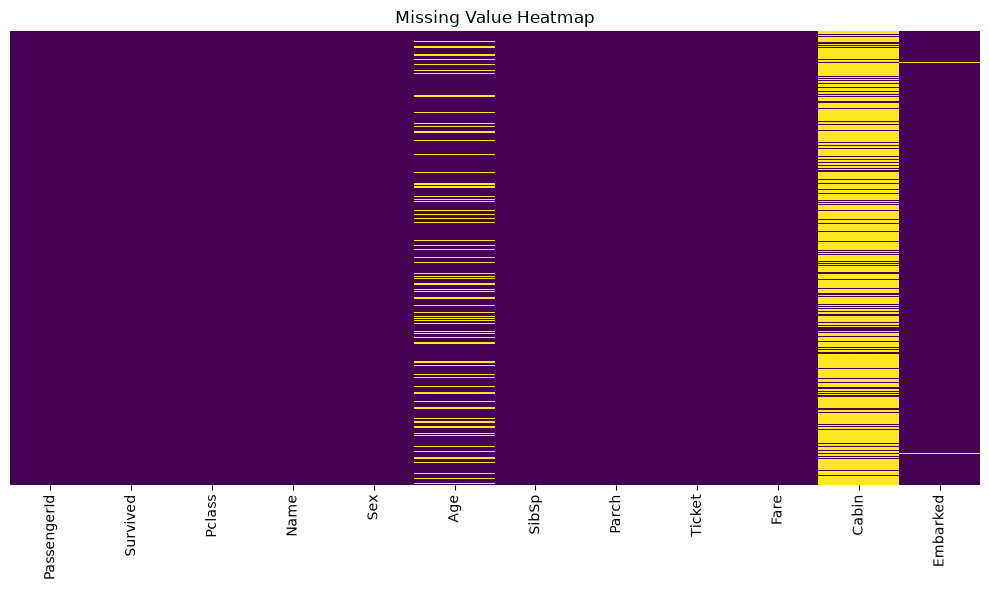

In [4]:
plt.figure(figsize=(10, 6))
sns.heatmap(titanic.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.show()

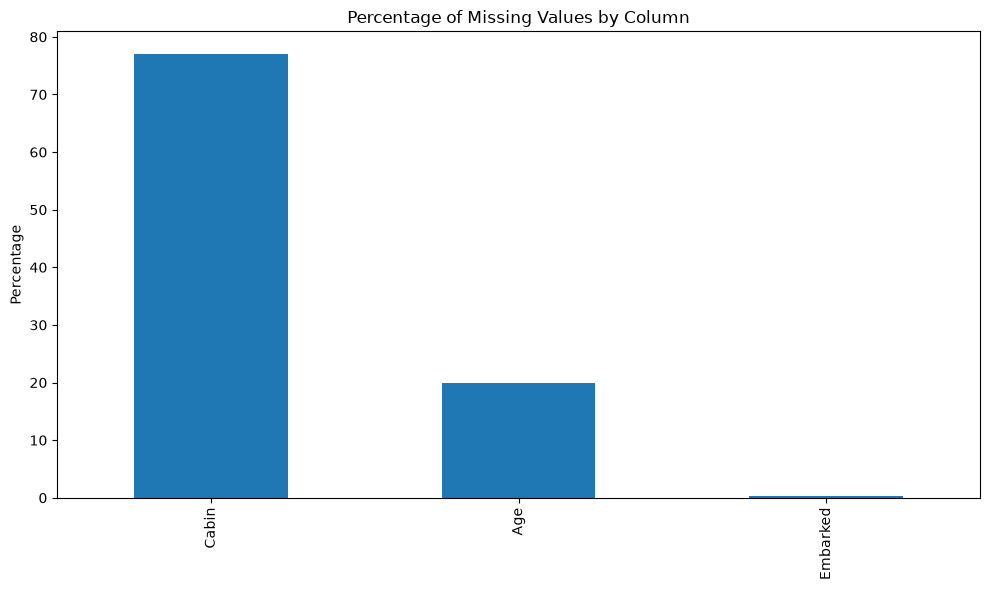

In [5]:
missing_percentage = titanic.isnull().mean() * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
missing_percentage.plot(kind='bar')
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage')
plt.tight_layout()
plt.show()

In [6]:
# 1. Drop Cabin and Ticket (high missing / less relevant)
titanic_reduced = titanic.drop(['Cabin', 'Ticket'], axis=1)

# 2. Impute Age using median grouped by Pclass
age_imputed = titanic_reduced.copy()
age_imputed['Age'] = age_imputed.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# 3. Create Age_Missing indicator
age_imputed['Age_Missing'] = titanic_reduced['Age'].isnull().astype(int)

# 4. Impute Embarked with mode
age_imputed['Embarked'] = age_imputed['Embarked'].fillna(age_imputed['Embarked'].mode()[0])

# 5. Verify no missing values
age_imputed.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Age_Missing    0
dtype: int64

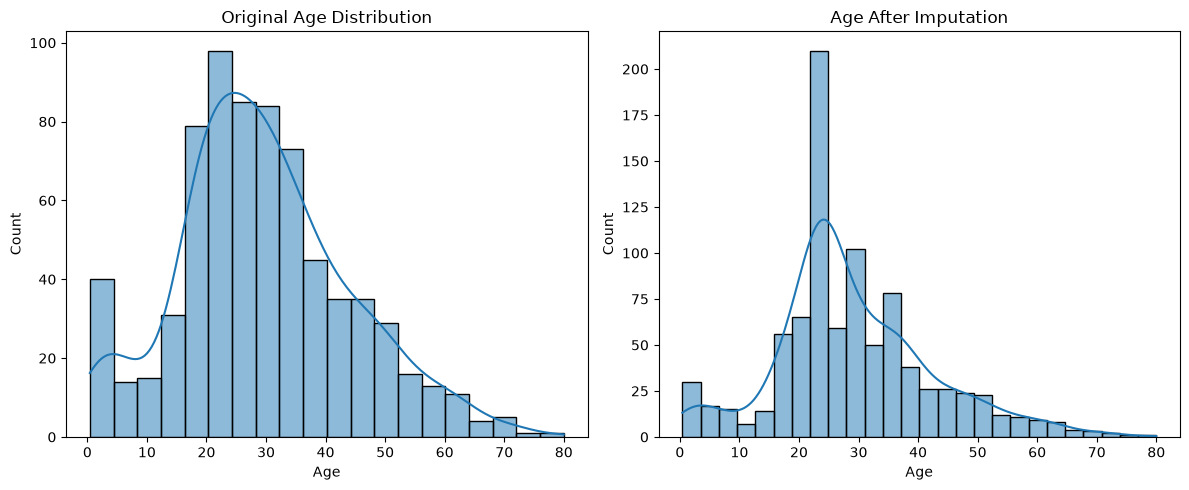

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(titanic['Age'].dropna(), kde=True)
plt.title('Original Age Distribution')

plt.subplot(1, 2, 2)
sns.histplot(age_imputed['Age'], kde=True)
plt.title('Age After Imputation')

plt.tight_layout()
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

X = age_imputed[features]
y = age_imputed[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardization
numeric_features = ['Age', 'Fare']
scaler = StandardScaler()

X_train_std = X_train.copy()
X_test_std = X_test.copy()
X_train_std[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_std[numeric_features] = scaler.transform(X_test[numeric_features])

# Min-Max Scaling
min_max_scaler = MinMaxScaler()
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()
X_train_norm[numeric_features] = min_max_scaler.fit_transform(X_train[numeric_features])
X_test_norm[numeric_features] = min_max_scaler.transform(X_test[numeric_features])

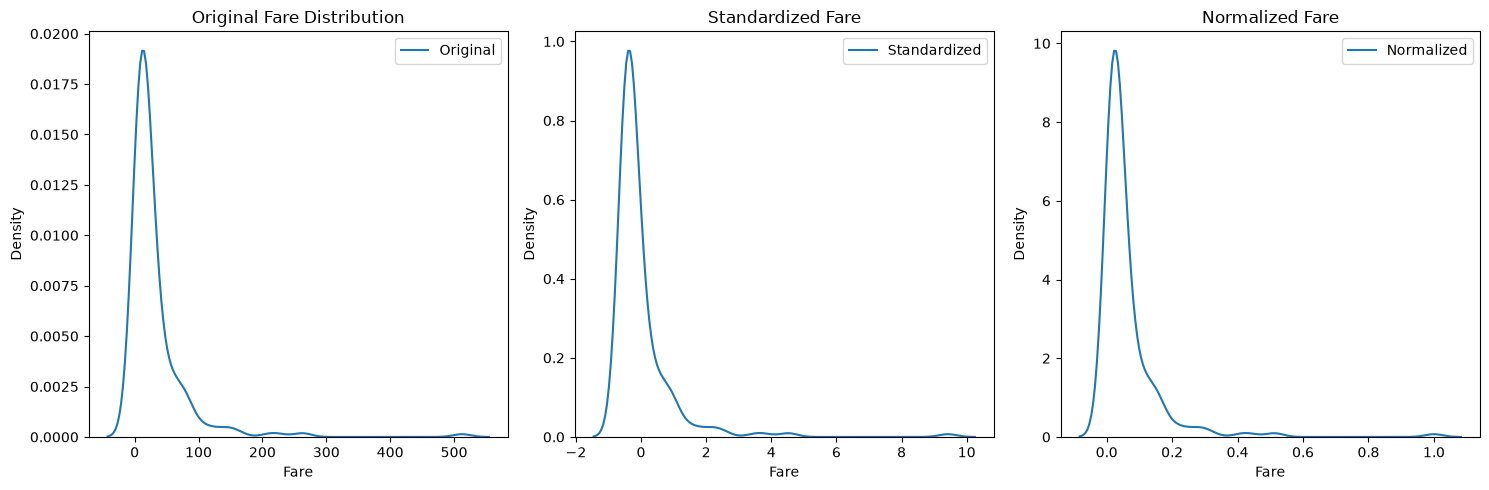

In [9]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.kdeplot(X_train['Fare'], label='Original')
plt.title('Original Fare Distribution')
plt.legend()

plt.subplot(1, 3, 2)
sns.kdeplot(X_train_std['Fare'], label='Standardized')
plt.title('Standardized Fare')
plt.legend()

plt.subplot(1, 3, 3)
sns.kdeplot(X_train_norm['Fare'], label='Normalized')
plt.title('Normalized Fare')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
# Label Encoding for Sex
label_encoder = LabelEncoder()
X_train_encoded = X_train_std.copy()
X_test_encoded = X_test_std.copy()

X_train_encoded['Sex'] = label_encoder.fit_transform(X_train_encoded['Sex'])
X_test_encoded['Sex'] = label_encoder.transform(X_test_encoded['Sex'])

# One-Hot Encoding for Embarked
embarked_ohe = OneHotEncoder(sparse_output=False, drop='first')
embarked_train_encoded = embarked_ohe.fit_transform(X_train_encoded[['Embarked']])
embarked_test_encoded = embarked_ohe.transform(X_test_encoded[['Embarked']])

# Create DataFrames
embarked_train_df = pd.DataFrame(
    embarked_train_encoded,
    columns=[f'Embarked_{c}' for c in embarked_ohe.categories_[0][1:]],
    index=X_train_encoded.index
)
embarked_test_df = pd.DataFrame(
    embarked_test_encoded,
    columns=[f'Embarked_{c}' for c in embarked_ohe.categories_[0][1:]],
    index=X_test_encoded.index
)

# Drop original Embarked and join encoded
X_train_encoded = X_train_encoded.drop('Embarked', axis=1).join(embarked_train_df)
X_test_encoded = X_test_encoded.drop('Embarked', axis=1).join(embarked_test_df)

# Display
print("Label Encoded 'Sex':")
print(X_train_encoded['Sex'].value_counts())

print("\nOne-Hot Encoded 'Embarked':")
print(X_train_encoded.filter(like='Embarked').head())

Label Encoded 'Sex':
Sex
1    410
0    213
Name: count, dtype: int64

One-Hot Encoded 'Embarked':
     Embarked_Q  Embarked_S
445         0.0         1.0
650         0.0         1.0
172         0.0         1.0
450         0.0         1.0
314         0.0         1.0


In [11]:
# Define transformers
num_features = ['Age', 'Fare']
cat_features = ['Sex', 'Embarked']

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Full pipeline with Logistic Regression
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Split raw data
X_full = age_imputed[features]
y_full = age_imputed[target]
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.3, random_state=42)

# Train
model_pipeline.fit(X_train, y_train)

# Predict & Evaluate
predictions = model_pipeline.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.7799

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       157
           1       0.75      0.70      0.73       111

    accuracy                           0.78       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



In [12]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(623, 7)
(623,)
(268, 7)
(268,)


In [13]:
from sklearn.model_selection import GridSearchCV

In [14]:
# Pipeline with RandomForest
tune_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

# Parameter grid
param_grid = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [None, 10],
    'preprocessor__num__imputer__strategy': ['mean', 'median']
}

grid_search = GridSearchCV(tune_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
print(f"Test set score: {grid_search.score(X_test, y_test):.4f}")

Best parameters: {'clf__max_depth': 10, 'clf__n_estimators': 100, 'preprocessor__num__imputer__strategy': 'mean'}
Best cross-validation score: 0.7962
Test set score: 0.7500


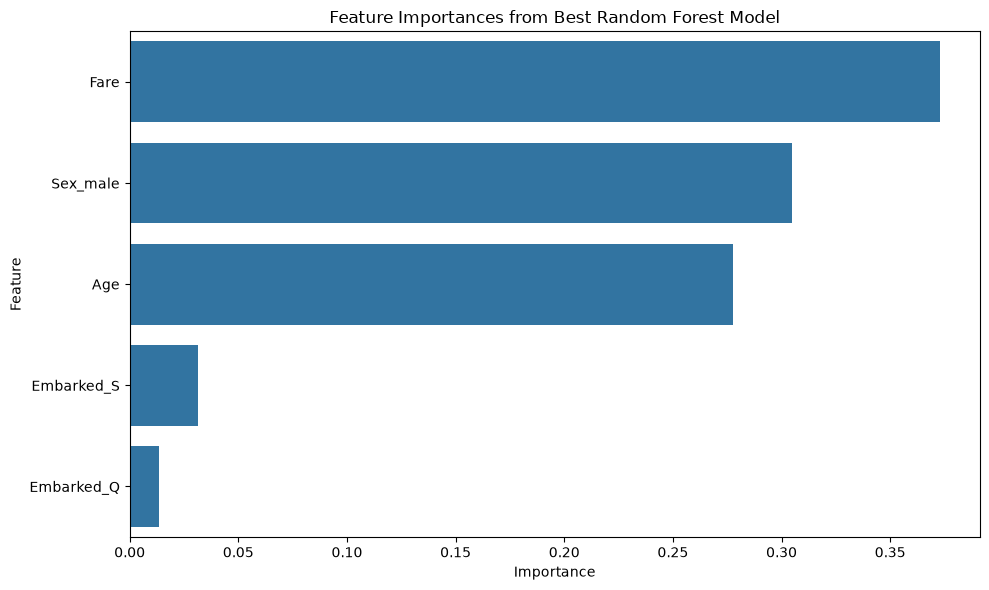

In [15]:
# Feature importance from best Random Forest model
best_rf = grid_search.best_estimator_.named_steps['clf']

# Get feature names after preprocessing
preprocessor = grid_search.best_estimator_.named_steps['preprocessor']
ohe_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(['Sex', 'Embarked'])
feature_names = np.concatenate([['Age', 'Fare'], ohe_features])

importances = best_rf.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from Best Random Forest Model')
plt.tight_layout()
plt.show()

TASK 1.2: Missing Values Count
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

TASK 1.3: Missing Value Heatmap


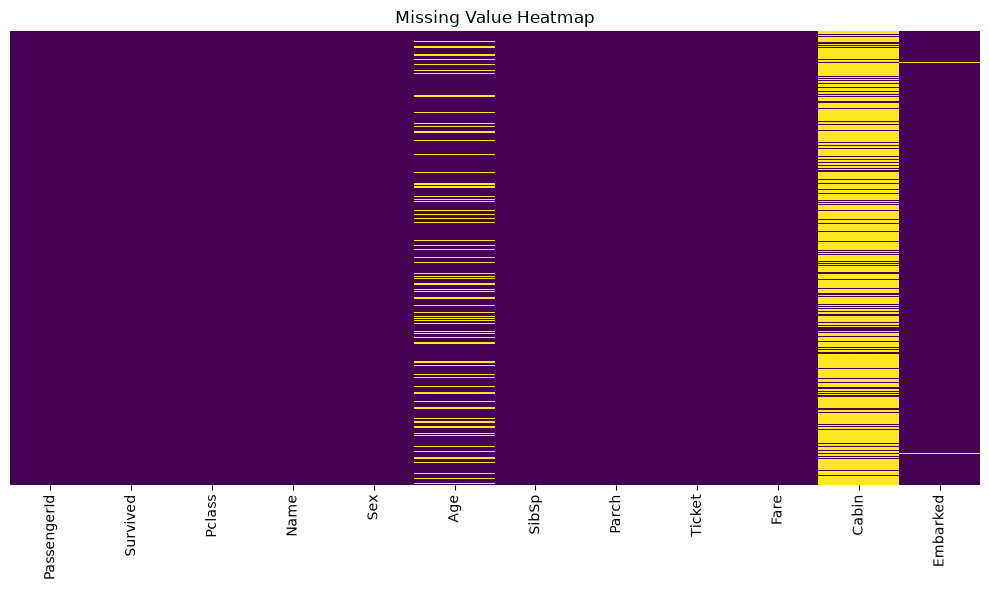


TASK 1.4: Missing Value Percentage Bar Plot


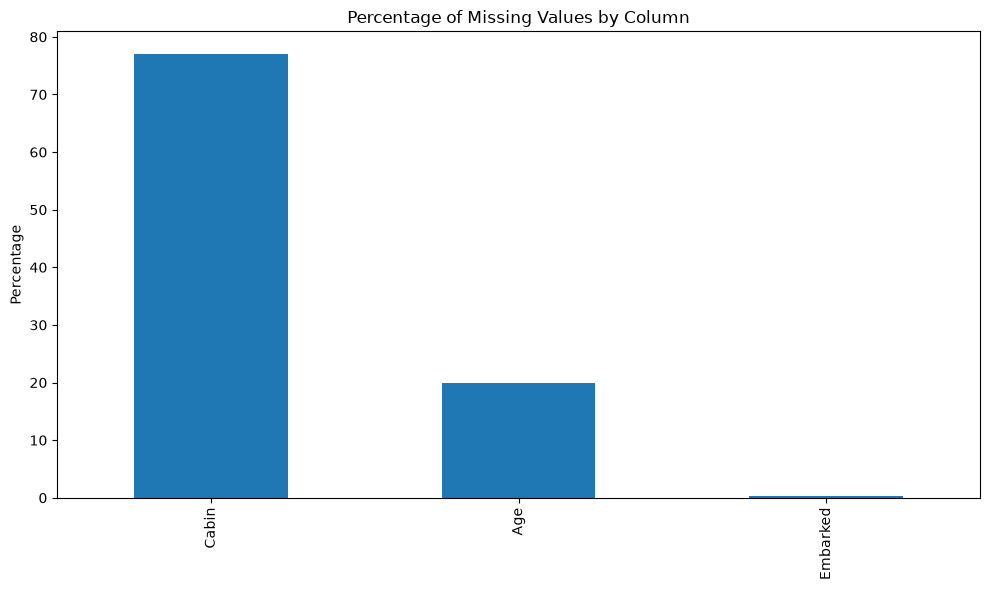

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# TASK 1.1: Load dataset
# ============================================
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

# ============================================
# TASK 1.2: Compute missing values per column
# ============================================
print("=" * 50)
print("TASK 1.2: Missing Values Count")
print("=" * 50)
print(titanic.isnull().sum())

# ============================================
# TASK 1.3: Visualize missingness with heatmap
# ============================================
print("\n" + "=" * 50)
print("TASK 1.3: Missing Value Heatmap")
print("=" * 50)
plt.figure(figsize=(10,6))
sns.heatmap(titanic.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.show()

# ============================================
# TASK 1.4: Percentage of missing values (bar plot)
# ============================================
print("\n" + "=" * 50)
print("TASK 1.4: Missing Value Percentage Bar Plot")
print("=" * 50)
missing_percentage = titanic.isnull().mean() * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
missing_percentage.plot(kind='bar')
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage')
plt.tight_layout()
plt.show()

In [17]:
# ============================================
# TASK 2: Handle Missing Values
# ============================================

# Start from a copy
df = titanic.copy()

# ============================================
# TASK 2.1: Drop columns with too many missing
# ============================================
print("=" * 50)
print("TASK 2.1: Dropping 'Cabin' and 'Ticket' columns")
print("=" * 50)
df = df.drop(['Cabin', 'Ticket'], axis=1)
print("Columns dropped: Cabin, Ticket")

# ============================================
# TASK 2.2: Impute Age by median within each Pclass
# ============================================
print("\n" + "=" * 50)
print("TASK 2.2: Imputing Age with median grouped by Pclass")
print("=" * 50)
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))
print("Age missing values filled with group median")

# ============================================
# TASK 2.3: Create Age_missing indicator column
# ============================================
print("\n" + "=" * 50)
print("TASK 2.3: Creating Age_Missing indicator column")
print("=" * 50)
df['Age_Missing'] = df['Age'].isnull().astype(int)
print("Age_Missing column created (1 = missing, 0 = not missing)")

# ============================================
# TASK 2.4: Impute Embarked with mode
# ============================================
print("\n" + "=" * 50)
print("TASK 2.4: Imputing Embarked with mode")
print("=" * 50)
mode_value = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_value)
print(f"Embarked missing values filled with mode: '{mode_value}'")

# ============================================
# TASK 2.5: Verify no more missing values
# ============================================
print("\n" + "=" * 50)
print("TASK 2.5: Verify no missing values remain")
print("=" * 50)
print(df.isnull().sum())
print("\n✅ All missing values handled successfully!")

TASK 2.1: Dropping 'Cabin' and 'Ticket' columns
Columns dropped: Cabin, Ticket

TASK 2.2: Imputing Age with median grouped by Pclass
Age missing values filled with group median

TASK 2.3: Creating Age_Missing indicator column
Age_Missing column created (1 = missing, 0 = not missing)

TASK 2.4: Imputing Embarked with mode
Embarked missing values filled with mode: 'S'

TASK 2.5: Verify no missing values remain
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Age_Missing    0
dtype: int64

✅ All missing values handled successfully!


TASK 3.1: Standardization (Z-score)
Standardization applied: mean=0, std=1

TASK 3.2: Min-Max Normalization
Min-Max Normalization applied: range 0 to 1

TASK 3.3: Visualization of Scaling Effects


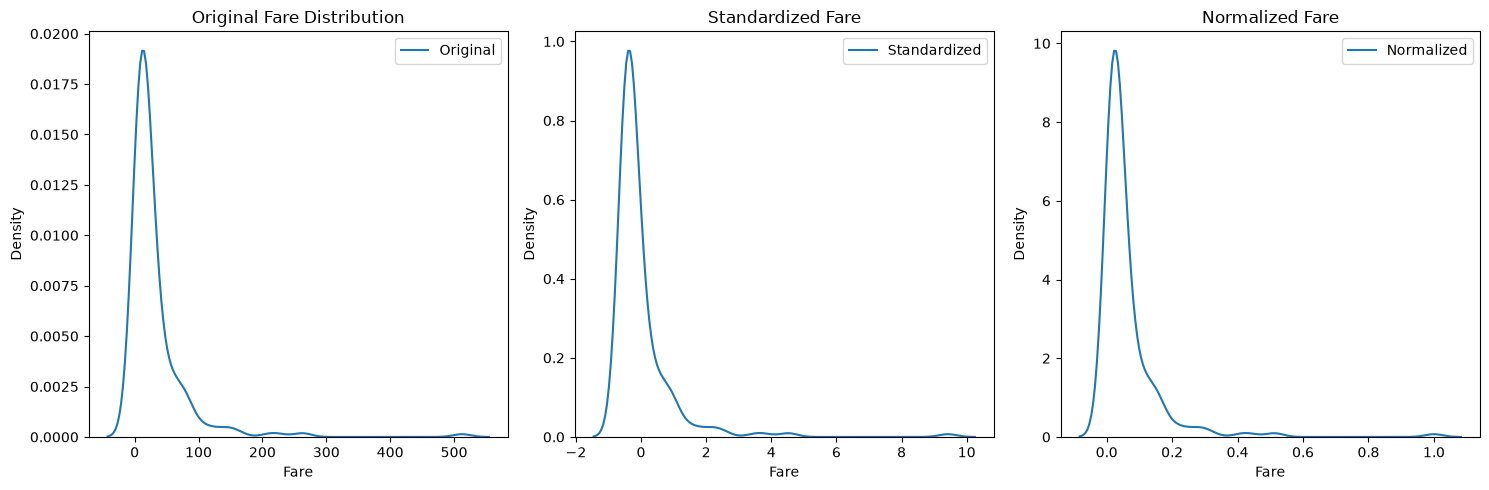

✅ All three scaling methods visualized successfully!


In [18]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# ============================================
# TASK 3: Feature Scaling
# ============================================

features = ['Age','Fare']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ============================================
# TASK 3.1: Standardization (Z-score normalization)
# ============================================
print("=" * 50)
print("TASK 3.1: Standardization (Z-score)")
print("=" * 50)
std = StandardScaler()
X_train_std = X_train.copy()
X_test_std = X_test.copy()
X_train_std[features] = std.fit_transform(X_train[features])
X_test_std[features] = std.transform(X_test[features])
print("Standardization applied: mean=0, std=1")

# ============================================
# TASK 3.2: Min-Max Normalization
# ============================================
print("\n" + "=" * 50)
print("TASK 3.2: Min-Max Normalization")
print("=" * 50)
mms = MinMaxScaler()
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()
X_train_norm[features] = mms.fit_transform(X_train[features])
X_test_norm[features] = mms.transform(X_test[features])
print("Min-Max Normalization applied: range 0 to 1")

# ============================================
# TASK 3.3: Plot distributions (Original vs Standardized vs Normalized)
# ============================================
print("\n" + "=" * 50)
print("TASK 3.3: Visualization of Scaling Effects")
print("=" * 50)
plt.figure(figsize=(15,5))

plt.subplot(1, 3, 1)
sns.kdeplot(X_train['Fare'], label='Original')
plt.title('Original Fare Distribution')
plt.legend()

plt.subplot(1, 3, 2)
sns.kdeplot(X_train_std['Fare'], label='Standardized')
plt.title('Standardized Fare')
plt.legend()

plt.subplot(1, 3, 3)
sns.kdeplot(X_train_norm['Fare'], label='Normalized')
plt.title('Normalized Fare')
plt.legend()
plt.tight_layout()
plt.show()
print("✅ All three scaling methods visualized successfully!")

In [19]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# ============================================
# TASK 4: Encode Categorical Features
# ============================================

X_cat = df[['Sex','Embarked']]

# ============================================
# TASK 4.1: Label Encoding for Sex (binary)
# ============================================
print("=" * 50)
print("TASK 4.1: Label Encoding - Sex column")
print("=" * 50)
le = LabelEncoder()
X_cat['Sex_le'] = le.fit_transform(X_cat['Sex'])
print("Sex encoded: Male → 0, Female → 1")
print(X_cat[['Sex', 'Sex_le']].head())

# ============================================
# TASK 4.2: One-Hot Encoding for Embarked
# ============================================
print("\n" + "=" * 50)
print("TASK 4.2: One-Hot Encoding - Embarked column")
print("=" * 50)
ohe = OneHotEncoder(sparse_output=False, drop='first')
embarked_encoded = ohe.fit_transform(X_cat[['Embarked']])
embarked_df = pd.DataFrame(
    embarked_encoded,
    columns=[f'Embarked_{c}' for c in ohe.categories_[0][1:]],
    index=X_cat.index
)

# ============================================
# TASK 4.3: Display encoded features
# ============================================
print("\n" + "=" * 50)
print("TASK 4.3: Final Encoded Features")
print("=" * 50)
print("\nOriginal Data:")
print(X_cat[['Sex', 'Embarked']].head())
print("\nEncoded Data:")
print(pd.concat([X_cat[['Sex_le']], embarked_df], axis=1).head())
print("\n✅ Categorical encoding completed successfully!")

TASK 4.1: Label Encoding - Sex column
Sex encoded: Male → 0, Female → 1
      Sex  Sex_le
0    male       1
1  female       0
2  female       0
3  female       0
4    male       1

TASK 4.2: One-Hot Encoding - Embarked column

TASK 4.3: Final Encoded Features

Original Data:
      Sex Embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S

Encoded Data:
   Sex_le  Embarked_Q  Embarked_S
0       1         0.0         1.0
1       0         0.0         0.0
2       0         0.0         1.0
3       0         0.0         1.0
4       1         0.0         1.0

✅ Categorical encoding completed successfully!


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ============================================
# TASK 5: Build Preprocessing + Model Pipeline
# ============================================

# ============================================
# TASK 5.1: Define transformers for numeric and categorical columns
# ============================================
print("=" * 50)
print("TASK 5.1: Defining Preprocessing Transformers")
print("=" * 50)

num_features = ['Age','Fare']
cat_features = ['Sex','Embarked']

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

print("Numeric transformer: Impute(median) + StandardScaler")
print("Categorical transformer: Impute(mode) + OneHotEncoder")

# ============================================
# TASK 5.2: Create full pipeline with Logistic Regression
# ============================================
print("\n" + "=" * 50)
print("TASK 5.2: Creating Pipeline with Logistic Regression")
print("=" * 50)

pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])
print("Pipeline created: Preprocessing → Logistic Regression")

# ============================================
# TASK 5.3: Train the pipeline and evaluate
# ============================================
print("\n" + "=" * 50)
print("TASK 5.3: Training and Evaluating the Model")
print("=" * 50)

X_full = df[num_features + cat_features]
y_full = df['Survived']
X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.3, random_state=42)

# Train the pipeline
pipe.fit(X_tr, y_tr)
print("✅ Model training complete!")

# Predict and evaluate
y_pred = pipe.predict(X_te)
print(f"\nAccuracy: {accuracy_score(y_te, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_te, y_pred))
print("\n✅ Pipeline model evaluation complete!")

TASK 5.1: Defining Preprocessing Transformers
Numeric transformer: Impute(median) + StandardScaler
Categorical transformer: Impute(mode) + OneHotEncoder

TASK 5.2: Creating Pipeline with Logistic Regression
Pipeline created: Preprocessing → Logistic Regression

TASK 5.3: Training and Evaluating the Model
✅ Model training complete!

Accuracy: 0.7799

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       157
           1       0.75      0.70      0.73       111

    accuracy                           0.78       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268


✅ Pipeline model evaluation complete!


TASK 6.1: Creating Pipeline with RandomForest
RandomForest pipeline created

TASK 6.2: Setting up Hyperparameter Grid
Parameter grid defined:
  - n_estimators: [50, 100]
  - max_depth: [None, 10]
  - imputer_strategy: ['mean', 'median']

TASK 6.3: Running GridSearchCV
✅ GridSearchCV training complete!

TASK 6.4: Best Parameters and Scores
Best parameters: {'clf__max_depth': 10, 'clf__n_estimators': 100, 'preproc__num__imputer__strategy': 'mean'}
Best cross-validation score: 0.7962

TASK 6.5: Test Set Evaluation
Test set score with best parameters: 0.7500

TASK 6.6 (BONUS): Feature Importance

Feature Importances:
      Feature  Importance
1        Fare    0.372690
2    Sex_male    0.304935
0         Age    0.277557
4  Embarked_S    0.031333
3  Embarked_Q    0.013485


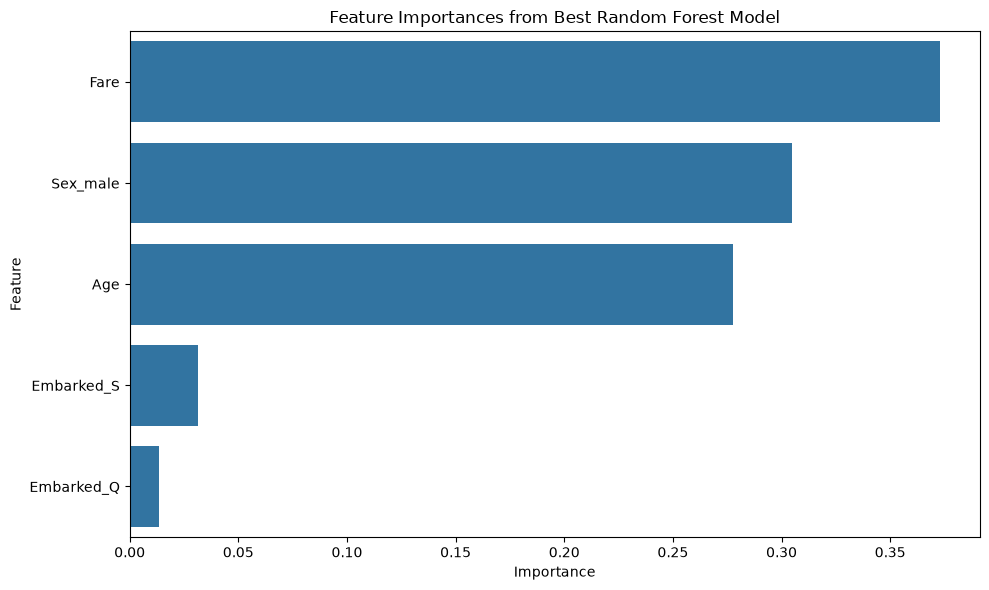


✅ Feature importance plot generated!

🎉 ALL TASKS COMPLETED SUCCESSFULLY!


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# ============================================
# TASK 6: Hyperparameter Tuning with GridSearchCV
# ============================================

# ============================================
# TASK 6.1: Replace classifier with RandomForest
# ============================================
print("=" * 50)
print("TASK 6.1: Creating Pipeline with RandomForest")
print("=" * 50)

tune_pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])
print("RandomForest pipeline created")

# ============================================
# TASK 6.2: Set up parameter grid
# ============================================
print("\n" + "=" * 50)
print("TASK 6.2: Setting up Hyperparameter Grid")
print("=" * 50)

param_grid = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [None, 10],
    'preproc__num__imputer__strategy': ['mean','median']
}
print("Parameter grid defined:")
print(f"  - n_estimators: {param_grid['clf__n_estimators']}")
print(f"  - max_depth: {param_grid['clf__max_depth']}")
print(f"  - imputer_strategy: {param_grid['preproc__num__imputer__strategy']}")

# ============================================
# TASK 6.3: Fit GridSearchCV
# ============================================
print("\n" + "=" * 50)
print("TASK 6.3: Running GridSearchCV")
print("=" * 50)

grid = GridSearchCV(tune_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_tr, y_tr)
print("✅ GridSearchCV training complete!")

# ============================================
# TASK 6.4: Print best parameters and scores
# ============================================
print("\n" + "=" * 50)
print("TASK 6.4: Best Parameters and Scores")
print("=" * 50)

print(f"Best parameters: {grid.best_params_}")
print(f"Best cross-validation score: {grid.best_score_:.4f}")

# ============================================
# TASK 6.5: Evaluate best estimator on test set
# ============================================
print("\n" + "=" * 50)
print("TASK 6.5: Test Set Evaluation")
print("=" * 50)

test_score = grid.best_estimator_.score(X_te, y_te)
print(f"Test set score with best parameters: {test_score:.4f}")

# ============================================
# TASK 6.6 (BONUS): Feature Importance Plot
# ============================================
print("\n" + "=" * 50)
print("TASK 6.6 (BONUS): Feature Importance")
print("=" * 50)

if hasattr(grid.best_estimator_.named_steps['clf'], 'feature_importances_'):
    preproc = grid.best_estimator_.named_steps['preproc']
    ohe_features = preproc.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(['Sex', 'Embarked'])
    feature_names = np.concatenate([num_features, ohe_features])
    importances = grid.best_estimator_.named_steps['clf'].feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importances:")
    print(importance_df)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title('Feature Importances from Best Random Forest Model')
    plt.tight_layout()
    plt.show()
    print("\n✅ Feature importance plot generated!")
else:
    print("Feature importance not available for this model")

print("\n" + "=" * 50)
print("🎉 ALL TASKS COMPLETED SUCCESSFULLY!")
print("=" * 50)